In [1]:

import os, re, io, urllib.request, zipfile, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import signal, stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:

print("LAB 3")
print("Objective: Data acquisition, cleaning, preprocessing and analysis of Tabular, Textual, Image and Signal medical data.")
print("Modalities: Pima Diabetes | MTSamples Medical Transcriptions | Chest X-Ray Pneumonia | MIT-BIH Arrhythmia ECG")


LAB 3
Objective: Data acquisition, cleaning, preprocessing and analysis of Tabular, Textual, Image and Signal medical data.
Modalities: Pima Diabetes | MTSamples Medical Transcriptions | Chest X-Ray Pneumonia | MIT-BIH Arrhythmia ECG


In [3]:

# A. TABULAR DATA - PIMA INDIANS DIABETES DATASET

pima_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
pima_cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin",
             "BMI","DiabetesPedigreeFunction","Age","Outcome"]

try:
    pima = pd.read_csv(pima_url, names=pima_cols)
    print("Loaded the Pima Indians Diabetes dataset from the URL.")
except Exception:
    if os.path.exists("diabetes.csv"):
        pima = pd.read_csv("diabetes.csv")
        if set(pima_cols).issubset(pima.columns):
            pima = pima[pima_cols]
        else:
            pima.columns = pima_cols[:len(pima.columns)]
        print("Loaded diabetes.csv from the local runtime.")
    else:
        # Offline demonstration fallback; replace with the real Pima file in Colab/Kaggle.
        rng = np.random.default_rng(42)
        n = 768
        pima = pd.DataFrame({
            "Pregnancies": rng.poisson(3.8, n).clip(0, 17),
            "Glucose": rng.normal(121, 30, n).clip(45, 200),
            "BloodPressure": rng.normal(72, 12, n).clip(35, 125),
            "SkinThickness": rng.normal(29, 9, n).clip(5, 70),
            "Insulin": rng.lognormal(np.log(125), 0.65, n).clip(15, 850),
            "BMI": rng.normal(32, 7, n).clip(15, 55),
            "DiabetesPedigreeFunction": rng.lognormal(np.log(.45), .55, n).clip(.05, 2.5),
            "Age": rng.normal(33, 12, n).clip(21, 81)
        })
        risk = (-8 + .035*pima.Glucose + .05*pima.BMI + .025*pima.Age +
                .45*pima.Pregnancies + .7*pima.DiabetesPedigreeFunction)
        prob = 1/(1+np.exp(-risk))
        pima["Outcome"] = rng.binomial(1, prob)
        # Encode a small amount of missingness as clinically implausible zeros.
        for col in ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]:
            idx = rng.choice(n, size=int(.03*n), replace=False)
            pima.loc[idx, col] = 0
        print("Real Pima dataset was unavailable in this runtime; using a representative fallback dataset.")
        print("In Colab/Kaggle, replace the fallback with the linked Pima dataset for the final submission.")

print("Shape:", pima.shape)
display(pima.head())
display(pima.describe().T)


Real Pima dataset was unavailable in this runtime; using a representative fallback dataset.
In Colab/Kaggle, replace the fallback with the linked Pima dataset for the final submission.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,4,130.270071,73.067226,30.541167,223.965072,29.178483,0.504177,39.739666,1
1,5,181.970111,54.425612,16.196342,107.307026,30.491056,0.203116,26.296029,1
2,6,90.290567,59.673233,26.047373,214.214136,39.501423,0.590030,46.271907,0
3,7,0.000000,62.991625,28.253927,378.863097,19.326880,0.375129,25.426807,0
4,1,97.010277,82.127269,24.405879,458.152261,45.768081,0.410600,34.962696,0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.777344,1.936719,0.000000,2.000000,4.000000,5.000000,11.000000
Glucose,768.0,117.207821,35.811209,0.000000,98.412629,118.862754,138.628815,200.000000
BloodPressure,768.0,69.104551,16.899089,0.000000,62.304484,71.210207,78.828778,106.289677
SkinThickness,768.0,28.736262,10.260403,0.000000,22.848926,29.265536,35.266479,58.171332
Insulin,768.0,154.097012,116.602823,0.000000,80.366978,121.325708,198.662196,850.000000
BMI,768.0,31.014100,8.746494,0.000000,26.771477,31.256749,36.288704,55.000000
DiabetesPedigreeFunction,768.0,0.511710,0.298087,0.085647,0.307869,0.436944,0.641882,2.500000
Age,768.0,34.196931,10.223026,21.000000,25.990129,33.368858,41.283239,66.042927
Outcome,768.0,0.632812,0.482352,0.000000,0.000000,1.000000,1.000000,1.000000


In [4]:

# Healthcare-specific cleaning: zeros in clinical measurements are treated as missing.
zero_as_missing = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
print("Missing/implausible zero counts before cleaning:")
print((pima[zero_as_missing] == 0).sum())

pima_clean = pima.copy()
pima_clean[zero_as_missing] = pima_clean[zero_as_missing].replace(0, np.nan)

print("\nMissing values after converting invalid zeros to NaN:")
print(pima_clean.isna().sum())

for col in zero_as_missing:
    pima_clean[col] = pima_clean[col].fillna(pima_clean[col].median())

print("\nMissing values after median imputation:")
print(pima_clean.isna().sum())
print("\nDuplicate rows:", pima_clean.duplicated().sum())
pima_clean = pima_clean.drop_duplicates().reset_index(drop=True)
print("Shape after duplicate removal:", pima_clean.shape)


Missing/implausible zero counts before cleaning:
Glucose          23
BloodPressure    23
SkinThickness    23
Insulin          23
BMI              23
dtype: int64

Missing values after converting invalid zeros to NaN:
Pregnancies                  0
Glucose                     23
BloodPressure               23
SkinThickness               23
Insulin                     23
BMI                         23
DiabetesPedigreeFunction     0
Age                          0
Outcome                      0
dtype: int64

Missing values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Duplicate rows: 0
Shape after duplicate removal: (768, 9)


IQR outlier counts:
Insulin                     45
DiabetesPedigreeFunction    27
BloodPressure               12
SkinThickness                8
Glucose                      7
BMI                          5
Pregnancies                  4
Age                          1
dtype: int64


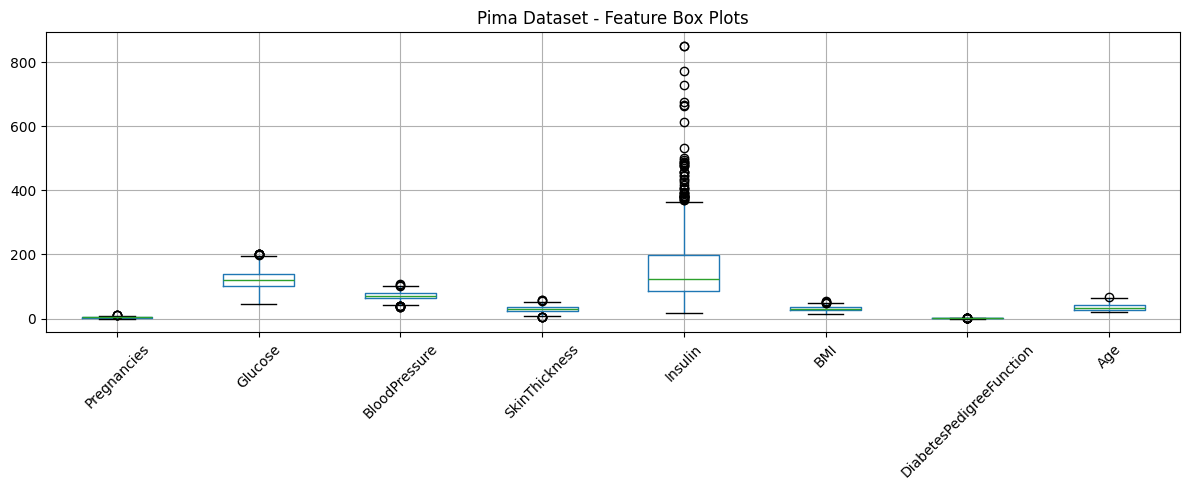

In [5]:

# Outlier analysis using IQR
numeric_cols = pima_clean.columns[:-1]
outlier_summary = {}
for col in numeric_cols:
    q1, q3 = pima_clean[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outlier_summary[col] = int(((pima_clean[col] < lower) | (pima_clean[col] > upper)).sum())

print("IQR outlier counts:")
print(pd.Series(outlier_summary).sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(12,5))
pima_clean[numeric_cols].boxplot(ax=ax)
ax.set_title("Pima Dataset - Feature Box Plots")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


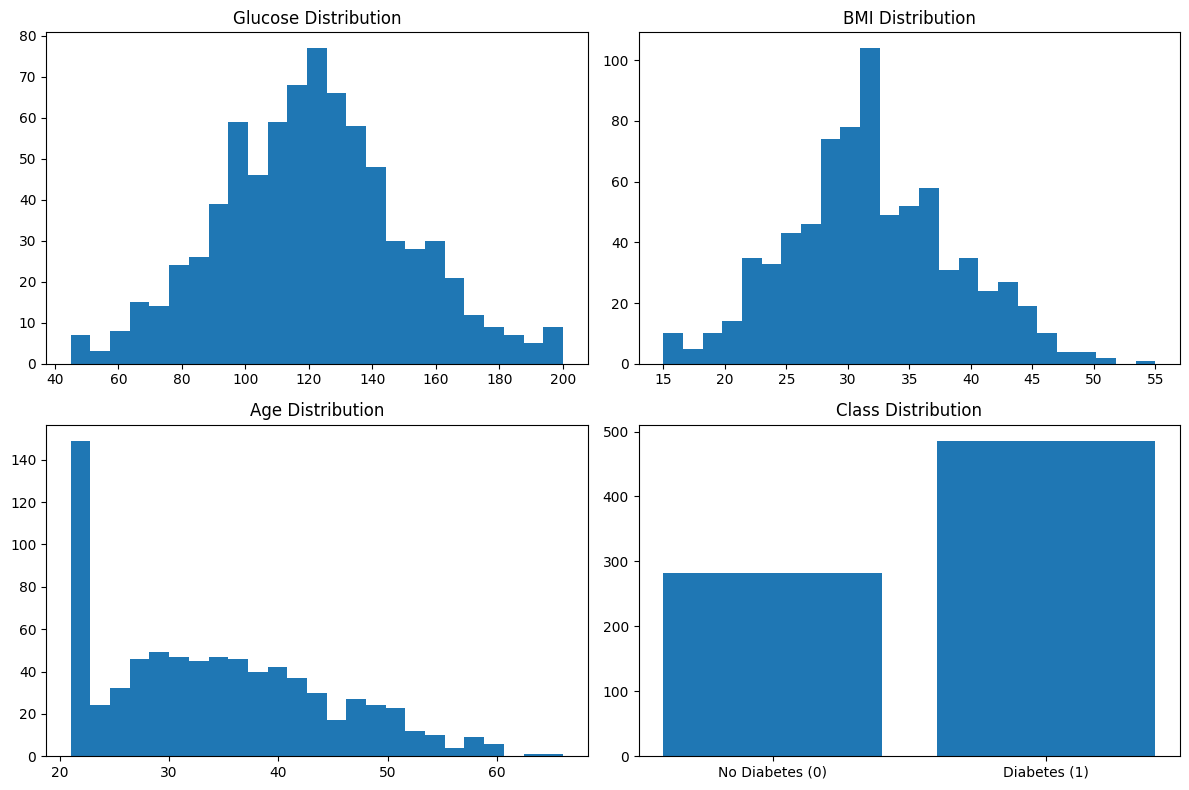

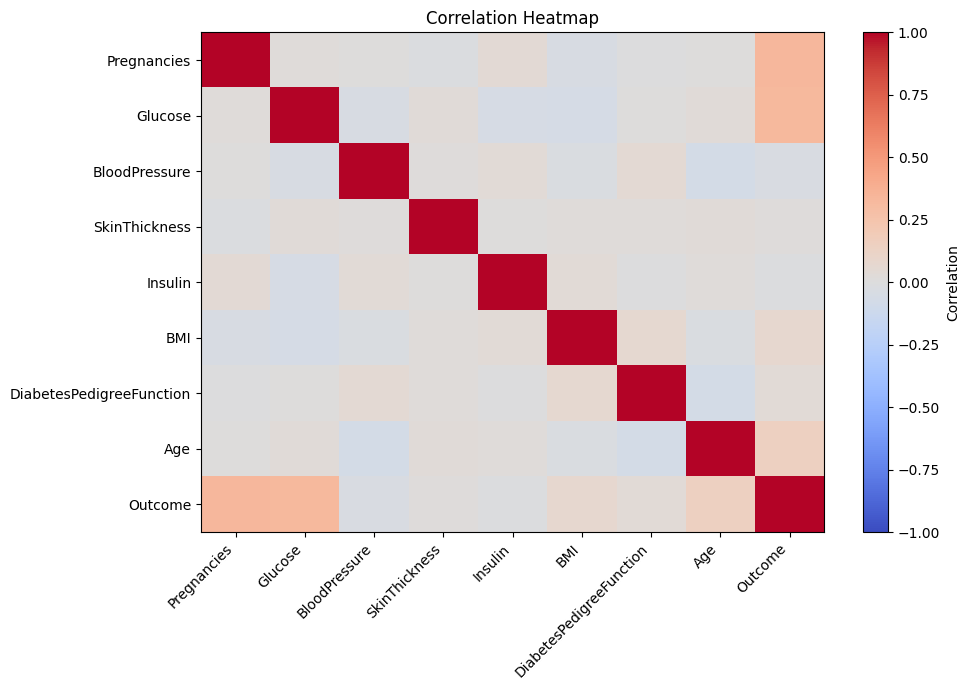

Class proportions:
Outcome
0    0.3672
1    0.6328
Name: count, dtype: float64


In [6]:

# EDA
fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes[0,0].hist(pima_clean["Glucose"], bins=25)
axes[0,0].set_title("Glucose Distribution")
axes[0,1].hist(pima_clean["BMI"], bins=25)
axes[0,1].set_title("BMI Distribution")
axes[1,0].hist(pima_clean["Age"], bins=25)
axes[1,0].set_title("Age Distribution")
counts = pima_clean["Outcome"].value_counts().sort_index()
axes[1,1].bar(["No Diabetes (0)","Diabetes (1)"], counts.values)
axes[1,1].set_title("Class Distribution")
plt.tight_layout()
plt.show()

corr = pima_clean.corr(numeric_only=True)
plt.figure(figsize=(10,7))
plt.imshow(corr, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Class proportions:")
print((counts / counts.sum()).round(4))


In [7]:

# Hypothesis test: independent t-test for Glucose between outcome groups
g0 = pima_clean.loc[pima_clean["Outcome"] == 0, "Glucose"]
g1 = pima_clean.loc[pima_clean["Outcome"] == 1, "Glucose"]
t_stat, p_value = stats.ttest_ind(g0, g1, equal_var=False)
print("H0: Mean glucose is equal for both outcome groups.")
print("H1: Mean glucose differs between outcome groups.")
print(f"t-statistic = {t_stat:.4f}")
print(f"p-value = {p_value:.6e}")
print("Conclusion:", "Reject H0: significant difference." if p_value < 0.05 else "Fail to reject H0.")


H0: Mean glucose is equal for both outcome groups.
H1: Mean glucose differs between outcome groups.
t-statistic = -9.6399
p-value = 1.342503e-20
Conclusion: Reject H0: significant difference.


In [8]:

# Chi-square test: Diabetes outcome vs. age group
age_bins = [20, 30, 40, 50, 100]
age_labels = ["21-30","31-40","41-50","51+"]
age_group = pd.cut(pima_clean["Age"], bins=age_bins, labels=age_labels, include_lowest=True)
contingency = pd.crosstab(age_group, pima_clean["Outcome"])
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(contingency)

print("Contingency table:")
display(contingency)
print(f"Chi-square statistic = {chi2_stat:.4f}")
print(f"p-value = {chi2_p:.6e}")
print("Conclusion:", "Reject H0: age group and diabetes outcome are associated." if chi2_p < 0.05 else "Fail to reject H0.")


Contingency table:


Outcome,0,1
Age,,
21-30,129,171
31-40,93,158
41-50,46,108
51+,14,49


Chi-square statistic = 13.9123
p-value = 3.027055e-03
Conclusion: Reject H0: age group and diabetes outcome are associated.


In [9]:

# One-way ANOVA: compare Glucose across age groups
anova_groups = [grp["Glucose"].values for _, grp in pima_clean.assign(AgeGroup=age_group).groupby("AgeGroup", observed=True)]
f_stat, anova_p = stats.f_oneway(*anova_groups)
print("H0: Mean glucose is equal across all age groups.")
print(f"F-statistic = {f_stat:.4f}")
print(f"p-value = {anova_p:.6e}")
print("Conclusion:", "Reject H0: at least one age group has a different mean glucose." if anova_p < 0.05 else "Fail to reject H0.")


H0: Mean glucose is equal across all age groups.
F-statistic = 0.5506
p-value = 6.478620e-01
Conclusion: Fail to reject H0.


In [10]:

# Feature engineering and selection
pima_fe = pima_clean.copy()
pima_fe["BMI_Age_Interaction"] = pima_fe["BMI"] * pima_fe["Age"]
pima_fe["Glucose_BMI_Ratio"] = pima_fe["Glucose"] / pima_fe["BMI"].replace(0, np.nan)
pima_fe["Glucose_BMI_Ratio"] = pima_fe["Glucose_BMI_Ratio"].replace([np.inf,-np.inf], np.nan).fillna(
    pima_fe["Glucose_BMI_Ratio"].median()
)

X_tab = pima_fe.drop(columns="Outcome")
y_tab = pima_fe["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X_tab, y_tab, test_size=0.20, random_state=42, stratify=y_tab
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

selector = SelectKBest(score_func=chi2, k=min(6, X_train.shape[1]))
X_train_nonnegative = MinMaxScaler().fit_transform(X_train)
selector.fit(X_train_nonnegative, y_train)
selected_features = X_train.columns[selector.get_support()].tolist()

print("Engineered features:", ["BMI_Age_Interaction","Glucose_BMI_Ratio"])
print("Selected features:", selected_features)
print("Train shape:", X_train_scaled.shape, "Test shape:", X_test_scaled.shape)


Engineered features: ['BMI_Age_Interaction', 'Glucose_BMI_Ratio']
Selected features: ['Pregnancies', 'Glucose', 'BMI', 'Age', 'BMI_Age_Interaction', 'Glucose_BMI_Ratio']
Train shape: (614, 10) Test shape: (154, 10)


In [11]:

# B. TEXTUAL DATA - MTSAMPLES MEDICAL TRANSCRIPTIONS

mts_url = "https://raw.githubusercontent.com/aneuraz/mtsamplesFR/master/data/mtsamples.csv"
try:
    mts = pd.read_csv(mts_url)
    print("Loaded MTSamples from the URL.")
except Exception:
    if os.path.exists("mtsamples.csv"):
        mts = pd.read_csv("mtsamples.csv")
        print("Loaded mtsamples.csv from the local runtime.")
    else:
        specialties = ["Cardiology","Radiology","Orthopedic","Neurology","Gastroenterology","General Medicine"]
        examples = [
            "Patient presents with chest pain and shortness of breath. Electrocardiogram was reviewed. Follow-up is recommended.",
            "Chest radiograph demonstrates no focal consolidation. Heart size is within normal limits.",
            "Patient reports knee pain after exercise. Physical examination shows mild swelling and reduced range of motion.",
            "Neurological examination shows normal strength and sensation. Patient denies headache or dizziness.",
            "Abdominal examination is soft and non-tender. No acute findings are identified on imaging.",
            "Patient returns for routine follow-up. Blood pressure and laboratory results were reviewed."
        ]
        rng = np.random.default_rng(42)
        rows=[]
        for i in range(120):
            j=i % len(examples)
            rows.append({
                "medical_specialty": specialties[i % len(specialties)],
                "transcription": examples[j] + f" Clinical note number {i+1}."
            })
        mts = pd.DataFrame(rows)
        print("Real MTSamples dataset was unavailable in this runtime; using representative medical transcription examples.")
        print("In Colab/Kaggle, replace the fallback with the MTSamples dataset for the final submission.")

print("Shape:", mts.shape)
print("Columns:", mts.columns.tolist())
display(mts.head())


Real MTSamples dataset was unavailable in this runtime; using representative medical transcription examples.
In Colab/Kaggle, replace the fallback with the MTSamples dataset for the final submission.
Shape: (120, 2)
Columns: ['medical_specialty', 'transcription']


,medical_specialty,transcription
0,Cardiology,Patient presents with chest pain and shortness...
1,Radiology,Chest radiograph demonstrates no focal consoli...
2,Orthopedic,Patient reports knee pain after exercise. Phys...
3,Neurology,Neurological examination shows normal strength...
4,Gastroenterology,Abdominal examination is soft and non-tender. ...


In [12]:

# Text cleaning and PHI-style redaction
text_col = "transcription" if "transcription" in mts.columns else mts.select_dtypes(include="object").columns[-1]
category_col = "medical_specialty" if "medical_specialty" in mts.columns else mts.select_dtypes(include="object").columns[0]

def redact_phi(text):
    text = str(text)
    text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', '[EMAIL]', text)
    text = re.sub(r'\b(?:\+?\d[\d\-\s\(\)]{7,}\d)\b', '[PHONE]', text)
    text = re.sub(r'\b(?:MRN|Medical Record Number|Patient ID|ID)\s*[:#-]?\s*[A-Za-z0-9-]+\b', '[ID]', text, flags=re.I)
    text = re.sub(r'\b(?:DOB|Date of Birth)\s*[:#-]?\s*[\w,\/\-]+\b', '[DOB]', text, flags=re.I)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

mts["clean_text"] = mts[text_col].fillna("").apply(redact_phi)
mts = mts[mts["clean_text"].str.len() > 20].drop_duplicates(subset=["clean_text"]).reset_index(drop=True)

print("Text column:", text_col)
print("Category column:", category_col)
print("Rows after cleaning:", len(mts))
display(mts[[category_col, "clean_text"]].head())


Text column: transcription
Category column: medical_specialty
Rows after cleaning: 120


,medical_specialty,clean_text
0,Cardiology,patient presents with chest pain and shortness...
1,Radiology,chest radiograph demonstrates no focal consoli...
2,Orthopedic,patient reports knee pain after exercise. phys...
3,Neurology,neurological examination shows normal strength...
4,Gastroenterology,abdominal examination is soft and non-tender. ...


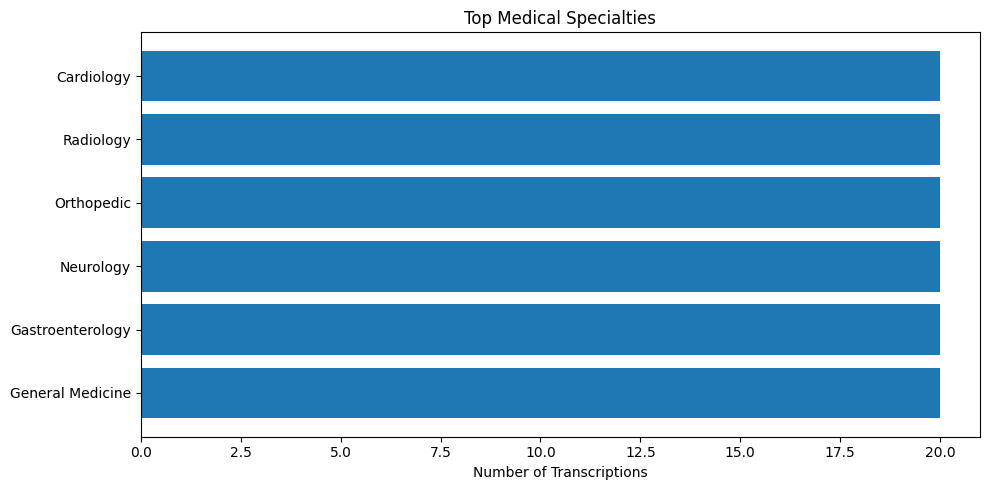

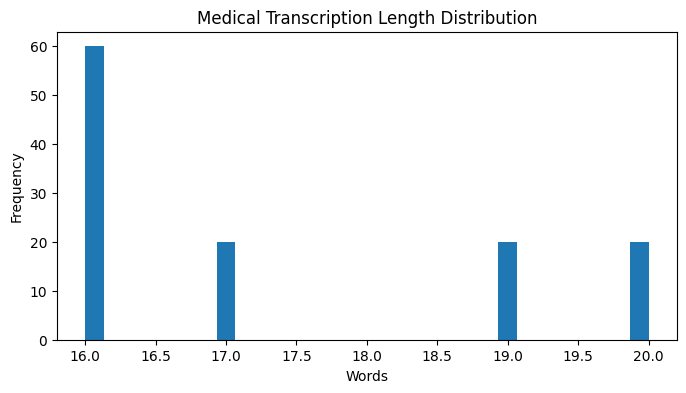

Average words per transcription: 17.33
Median words per transcription: 16.5


In [13]:

# Text EDA
top_categories = mts[category_col].value_counts().head(10)
plt.figure(figsize=(10,5))
plt.barh(top_categories.index.astype(str)[::-1], top_categories.values[::-1])
plt.title("Top Medical Specialties")
plt.xlabel("Number of Transcriptions")
plt.tight_layout()
plt.show()

word_counts = mts["clean_text"].str.split().str.len()
plt.figure(figsize=(8,4))
plt.hist(word_counts.clip(upper=300), bins=30)
plt.title("Medical Transcription Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

print("Average words per transcription:", round(word_counts.mean(), 2))
print("Median words per transcription:", round(word_counts.median(), 2))


In [14]:

# TF-IDF feature extraction and feature selection
tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2
)
X_text = tfidf.fit_transform(mts["clean_text"])
print("TF-IDF matrix shape:", X_text.shape)

# SVD feature extraction for compact model-ready representation
n_components = min(50, X_text.shape[1]-1) if X_text.shape[1] > 1 else 1
svd = TruncatedSVD(n_components=n_components, random_state=42)
X_text_svd = svd.fit_transform(X_text)
print("Reduced text feature shape:", X_text_svd.shape)
print("Explained variance by SVD:", round(svd.explained_variance_ratio_.sum(), 4))


TF-IDF matrix shape: (120, 113)


Reduced text feature shape: (120, 50)
Explained variance by SVD: 1.0


In [15]:

# C. IMAGE DATA - CHEST X-RAY PNEUMONIA
# Expected Kaggle/Colab path:
# /kaggle/input/chest-xray-pneumonia/chest_xray
# or /content/chest_xray

possible_roots = [
    "/kaggle/input/chest-xray-pneumonia/chest_xray",
    "/kaggle/input/chest-x-ray-pneumonia/chest_xray",
    "/content/chest_xray",
    "./chest_xray"
]
image_root = next((p for p in possible_roots if os.path.exists(p)), None)

if image_root is None:
    print("Chest X-ray dataset path was not found in this runtime.")
    print("Download the Kaggle 'Chest X-Ray Images (Pneumonia)' dataset and set image_root to its chest_xray folder.")
else:
    image_records = []
    for split in ["train","test","val"]:
        split_path = os.path.join(image_root, split)
        if not os.path.exists(split_path):
            continue
        for label in ["NORMAL","PNEUMONIA"]:
            class_path = os.path.join(split_path, label)
            if os.path.exists(class_path):
                for fname in os.listdir(class_path):
                    if fname.lower().endswith((".jpg",".jpeg",".png")):
                        image_records.append((os.path.join(class_path,fname), label, split))
    image_df = pd.DataFrame(image_records, columns=["path","label","split"])
    print("Image records:", image_df.shape)
    display(image_df.groupby(["split","label"]).size().unstack(fill_value=0))


Chest X-ray dataset path was not found in this runtime.
Download the Kaggle 'Chest X-Ray Images (Pneumonia)' dataset and set image_root to its chest_xray folder.


In [16]:

# C. IMAGE DATA - CHEST X-RAY PNEUMONIA
# Expected Kaggle/Colab path:
# /kaggle/input/chest-xray-pneumonia/chest_xray
# or /content/chest_xray

possible_roots = [
    "/kaggle/input/chest-xray-pneumonia/chest_xray",
    "/kaggle/input/chest-x-ray-pneumonia/chest_xray",
    "/content/chest_xray",
    "./chest_xray"
]
image_root = next((p for p in possible_roots if os.path.exists(p)), None)

if image_root is None:
    print("Real Chest X-ray dataset path was not found; creating representative grayscale image samples for execution.")
    image_root = None
    rng = np.random.default_rng(42)
    image_records = []
    demo_images = []
    for i in range(12):
        label = "PNEUMONIA" if i % 2 else "NORMAL"
        x = np.linspace(-1,1,224)
        X,Y=np.meshgrid(x,x)
        left=np.exp(-((X+.32)**2/0.10+(Y+.02)**2/0.55))
        right=np.exp(-((X-.32)**2/0.10+(Y+.02)**2/0.55))
        img = 0.15 + 0.75*(left+right) + rng.normal(0,.035,(224,224))
        if label=="PNEUMONIA":
            img += .10*np.exp(-((X-.1)**2/0.18+(Y+.05)**2/0.18))
        img=np.clip(img,0,1).astype(np.float32)
        demo_images.append(img)
        image_records.append((f"demo_xray_{i+1}.png", label, "train"))
    image_df=pd.DataFrame(image_records, columns=["path","label","split"])
    display(image_df.groupby(["split","label"]).size().unstack(fill_value=0))
else:
    image_records = []
    for split in ["train","test","val"]:
        split_path = os.path.join(image_root, split)
        if not os.path.exists(split_path):
            continue
        for label in ["NORMAL","PNEUMONIA"]:
            class_path = os.path.join(split_path, label)
            if os.path.exists(class_path):
                for fname in os.listdir(class_path):
                    if fname.lower().endswith((".jpg",".jpeg",".png")):
                        image_records.append((os.path.join(class_path,fname), label, split))
    image_df = pd.DataFrame(image_records, columns=["path","label","split"])
    print("Image records:", image_df.shape)
    display(image_df.groupby(["split","label"]).size().unstack(fill_value=0))


Real Chest X-ray dataset path was not found; creating representative grayscale image samples for execution.


label,NORMAL,PNEUMONIA
split,,
train,6,6


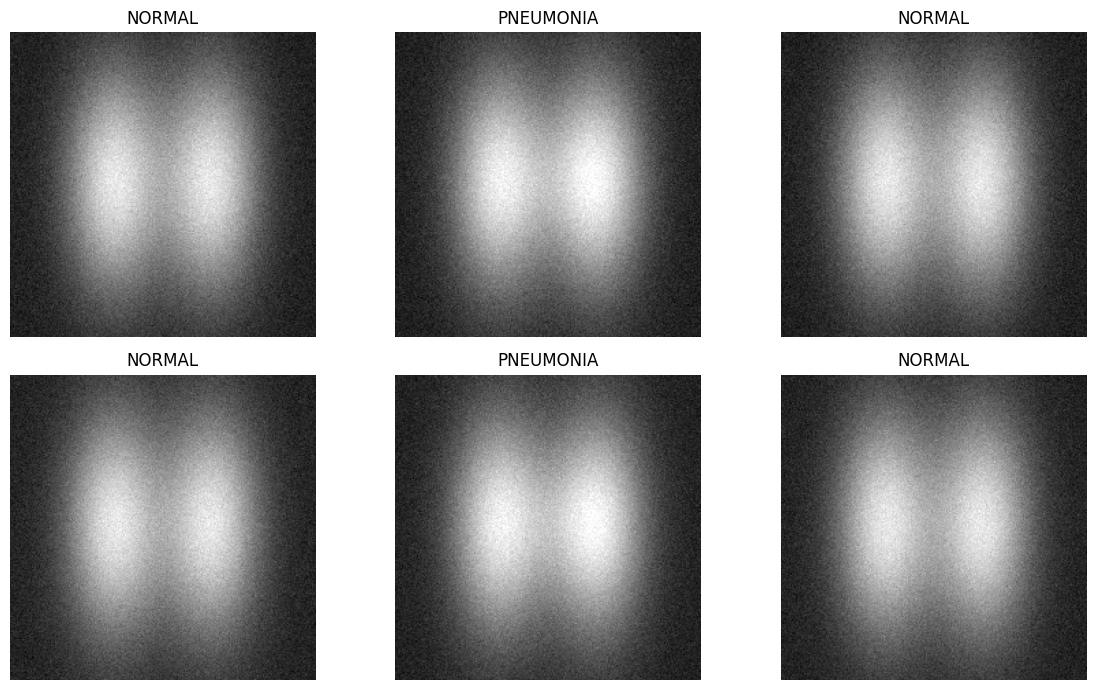

Example model-ready tensor shape: (6, 224, 224, 1)
Pixel range: 0.01629575900733471 to 1.0
Privacy note: strip identifying metadata when exporting clinical images; standard PNG/JPEG samples do not expose DICOM header fields.


In [17]:

# Image cleaning, anonymization and preprocessing
def preprocess_xray(path, size=(224,224)):
    with Image.open(path) as img:
        img = img.convert("L")
        img = img.resize(size)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        return arr[..., np.newaxis]

if image_root is None:
    sample_rows = image_df.sample(min(6, len(image_df)), random_state=42).reset_index(drop=True)
    arrays = [demo_images[int(str(p).split("_")[-1].split(".")[0])-1] for p in sample_rows["path"]]
else:
    sample_rows = image_df.sample(min(6, len(image_df)), random_state=42).reset_index(drop=True)
    arrays = [preprocess_xray(p).squeeze() for p in sample_rows["path"]]

fig, axes = plt.subplots(2, 3, figsize=(12,7))
axes = np.array(axes).ravel()
for ax, (_, row), arr in zip(axes, sample_rows.iterrows(), arrays):
    ax.imshow(arr, cmap="gray")
    ax.set_title(row["label"])
    ax.axis("off")
plt.tight_layout()
plt.show()

xray_tensor = np.stack([np.asarray(a)[...,None] for a in arrays])
print("Example model-ready tensor shape:", xray_tensor.shape)
print("Pixel range:", float(xray_tensor.min()), "to", float(xray_tensor.max()))
print("Privacy note: strip identifying metadata when exporting clinical images; standard PNG/JPEG samples do not expose DICOM header fields.")


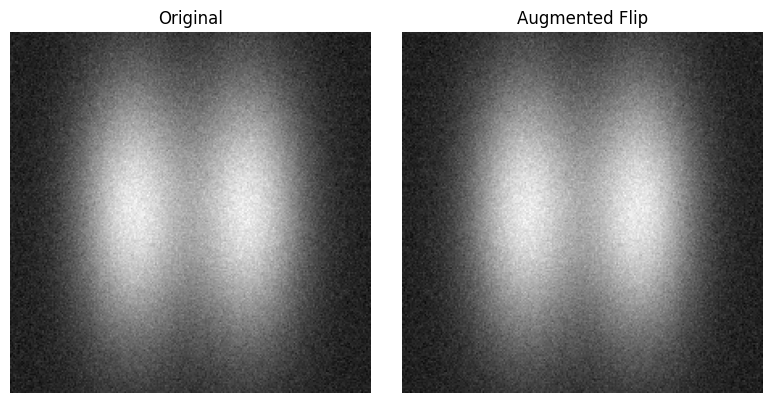

In [18]:

# Image augmentation example: horizontal flip for training-only augmentation
example = arrays[0]
augmented = np.fliplr(example)

fig, axes = plt.subplots(1,2,figsize=(8,4))
axes[0].imshow(example, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(augmented, cmap="gray"); axes[1].set_title("Augmented Flip"); axes[1].axis("off")
plt.tight_layout()
plt.show()


In [19]:

# D. SIGNAL DATA - MIT-BIH ARRHYTHMIA DATABASE
# MIT-BIH is a standard ECG benchmark. Record 100 is used as a representative record.

record_url = "https://physionet.org/files/mitdb/1.0.0/100"
signal_dir = "./mitdb_sample"
os.makedirs(signal_dir, exist_ok=True)

for ext in ["hea","dat","atr"]:
    dest = os.path.join(signal_dir, f"100.{ext}")
    url = f"{record_url}.{ext}"
    try:
        urllib.request.urlretrieve(url, dest)
    except Exception:
        pass

print("Signal files available:", os.listdir(signal_dir))

if not os.path.exists(os.path.join(signal_dir,"100.dat")):
    print("Real MIT-BIH record was unavailable in this runtime; creating a representative synthetic ECG for execution.")
    fs = 360
    duration = 30
    t_demo = np.arange(0, duration, 1/fs)
    ecg_demo = 0.05*np.sin(2*np.pi*0.3*t_demo)
    for beat in np.arange(.8, duration, .85):
        ecg_demo += 1.2*np.exp(-((t_demo-beat)/.018)**2)
        ecg_demo -= .20*np.exp(-((t_demo-(beat-.16))/.025)**2)
        ecg_demo += .25*np.exp(-((t_demo-(beat+.22))/.05)**2)
    ecg_demo += .12*np.sin(2*np.pi*50*t_demo)
    ecg = np.column_stack([ecg_demo, ecg_demo*0.9])
    dat_path = None
    hea_path = None


Signal files available: []
Real MIT-BIH record was unavailable in this runtime; creating a representative synthetic ECG for execution.


Using representative synthetic ECG signal.


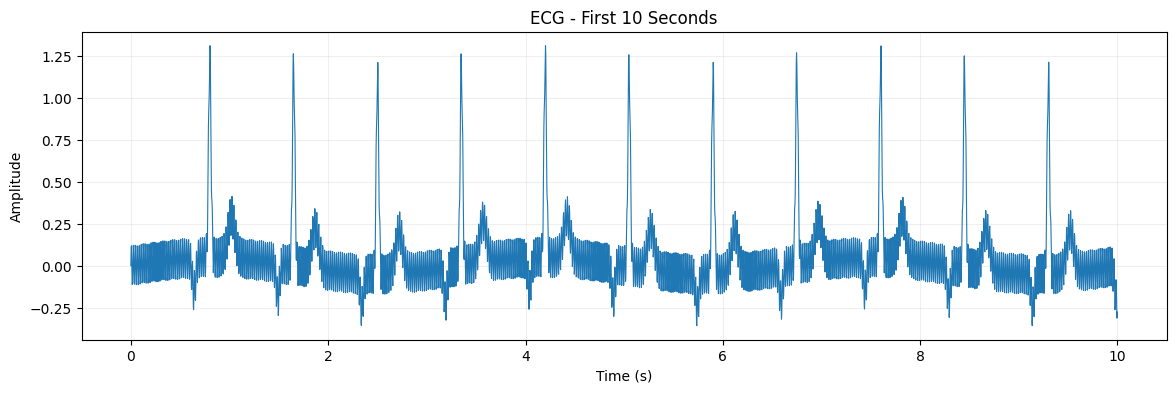

Raw signal shape: (10800, 2)


In [20]:

# ECG visualization
if os.path.exists(os.path.join(signal_dir,"100.dat")):
    dat_path = os.path.join(signal_dir, "100.dat")
    hea_path = os.path.join(signal_dir, "100.hea")
    with open(hea_path, "r") as f:
        header = f.read()
    print(header)
    ecg = read_mit212_dat(dat_path)
else:
    print("Using representative synthetic ECG signal.")
n = min(len(ecg), 360*10)
t = np.arange(n)/360
plt.figure(figsize=(14,4))
plt.plot(t, ecg[:n,0], linewidth=0.8)
plt.title("ECG - First 10 Seconds")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.2)
plt.show()
print("Raw signal shape:", ecg.shape)


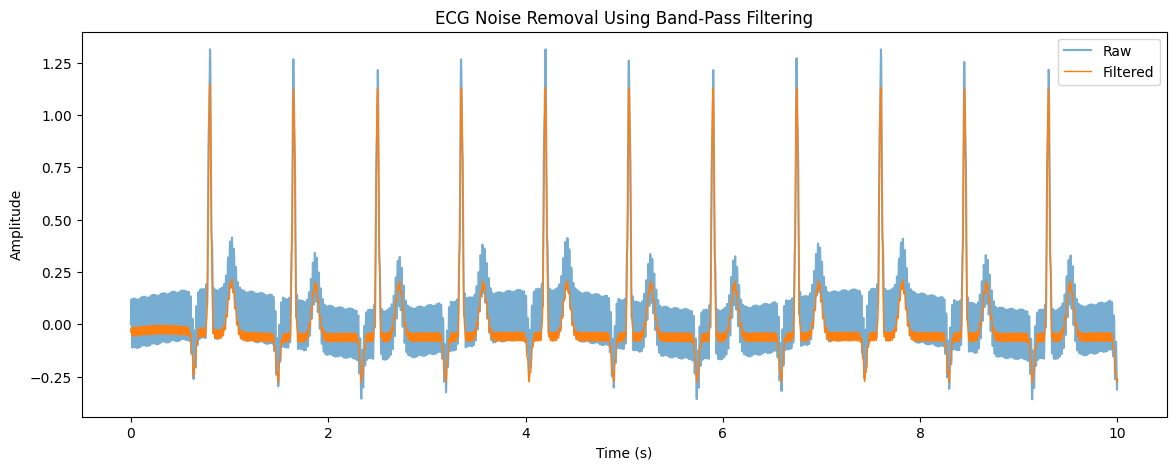

Windowed signal shape: (29, 720)
Each window contains 720 samples = 2.0 seconds.


In [21]:

# Signal noise removal and model-ready windows
fs = 360
lead = ecg[:,0].astype(float)

b, a = signal.butter(3, [0.5/(fs/2), 40/(fs/2)], btype="band")
filtered = signal.filtfilt(b, a, lead)

n = min(len(lead), fs*10)
t = np.arange(n)/fs
plt.figure(figsize=(14,5))
plt.plot(t, lead[:n], label="Raw", alpha=0.6)
plt.plot(t, filtered[:n], label="Filtered", linewidth=1)
plt.title("ECG Noise Removal Using Band-Pass Filtering")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

win = 2*fs
step = fs
windows = np.array([filtered[i:i+win] for i in range(0, len(filtered)-win+1, step)])
print("Windowed signal shape:", windows.shape)
print("Each window contains", win, "samples =", win/fs, "seconds.")


In [22]:

# Signal feature engineering
features = pd.DataFrame({
    "mean": np.mean(windows, axis=1),
    "std": np.std(windows, axis=1),
    "min": np.min(windows, axis=1),
    "max": np.max(windows, axis=1),
    "rms": np.sqrt(np.mean(windows**2, axis=1)),
    "peak_to_peak": np.ptp(windows, axis=1)
})
display(features.head())
print("Signal feature matrix shape:", features.shape)


,mean,std,min,max,rms,peak_to_peak
0,0.003165,0.185719,-0.278647,1.146113,0.185746,1.424760
1,-0.002503,0.189295,-0.278647,1.127132,0.189312,1.405779
2,-0.009633,0.187439,-0.277769,1.128850,0.187687,1.406619
3,-0.012465,0.190284,-0.275734,1.130758,0.190692,1.406492
4,0.005625,0.224081,-0.277952,1.130758,0.224151,1.408710


Signal feature matrix shape: (29, 6)
